In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

n = 300
segment = np.random.choice(['A', 'B', 'C'], size=n, p=[0.4, 0.4, 0.2])
x = np.random.normal(50, 10, n)
# segment C behaves differently on purpose, to give the subgroup check something to find
noise = np.where(segment == 'C', np.random.normal(0, 25, n), np.random.normal(0, 8, n))
y = 2 * x + 5 + noise

df = pd.DataFrame({'x': x, 'segment': segment, 'y': y})

# sprinkle in some missing values for the imputation scenario
missing_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[missing_idx, 'x'] = np.nan

os.makedirs('data/raw', exist_ok=True)
df.to_csv('data/raw/data_stage11_eval_risk.csv', index=False)
df.head()

,x,segment,y
0,NaN,A,97.878311
1,43.483997,C,61.692588
2,71.439441,B,147.601403
3,56.339190,B,119.552098
4,29.748574,A,76.901152


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

df_clean = df.dropna(subset=['x'])   # baseline: just drop missing
X = df_clean[['x']]
y = df_clean['y']

model = LinearRegression().fit(X, y)
preds = model.predict(X)
baseline_mae = mean_absolute_error(y, preds)
print("Baseline MAE:", round(baseline_mae, 3))

Baseline MAE: 8.601


In [3]:
np.random.seed(42)
n_boot = 500
boot_maes = []

for _ in range(n_boot):
    sample = df_clean.sample(n=len(df_clean), replace=True)   # resample WITH replacement
    X_s, y_s = sample[['x']], sample['y']
    m = LinearRegression().fit(X_s, y_s)
    boot_maes.append(mean_absolute_error(y_s, m.predict(X_s)))

ci_lower = np.percentile(boot_maes, 2.5)
ci_upper = np.percentile(boot_maes, 97.5)
print(f"95% CI for MAE: [{ci_lower:.3f}, {ci_upper:.3f}]")

95% CI for MAE: [7.469, 9.895]


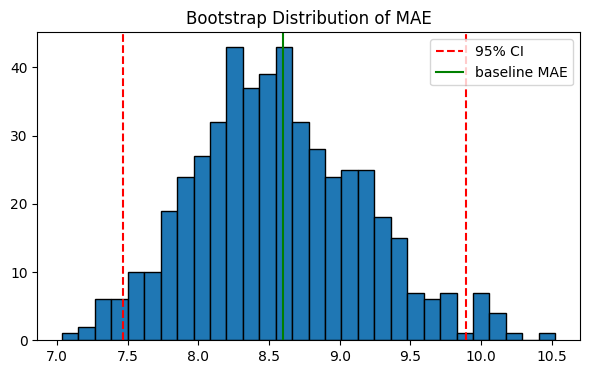

In [4]:
plt.figure(figsize=(7, 4))
plt.hist(boot_maes, bins=30, edgecolor='black')
plt.axvline(ci_lower, color='red', linestyle='--', label='95% CI')
plt.axvline(ci_upper, color='red', linestyle='--')
plt.axvline(baseline_mae, color='green', label='baseline MAE')
plt.legend()
plt.title('Bootstrap Distribution of MAE')
plt.show()

In [5]:
def fit_and_mae(data):
    X, y = data[['x']], data['y']
    m = LinearRegression().fit(X, y)
    return mean_absolute_error(y, m.predict(X))

df_mean_imputed = df.copy()
df_mean_imputed['x'] = df_mean_imputed['x'].fillna(df_mean_imputed['x'].mean())

df_median_imputed = df.copy()
df_median_imputed['x'] = df_median_imputed['x'].fillna(df_median_imputed['x'].median())

mae_mean = fit_and_mae(df_mean_imputed)
mae_median = fit_and_mae(df_median_imputed)

print("Mean imputation MAE:", round(mae_mean, 3))
print("Median imputation MAE:", round(mae_median, 3))

Mean imputation MAE: 9.327
Median imputation MAE: 9.329


In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(df_clean[['x']], df_clean['y'])
poly_preds = poly_model.predict(df_clean[['x']])
mae_poly = mean_absolute_error(df_clean['y'], poly_preds)

print("Linear MAE:", round(baseline_mae, 3))
print("Polynomial (degree 2) MAE:", round(mae_poly, 3))

Linear MAE: 8.601
Polynomial (degree 2) MAE: 8.609


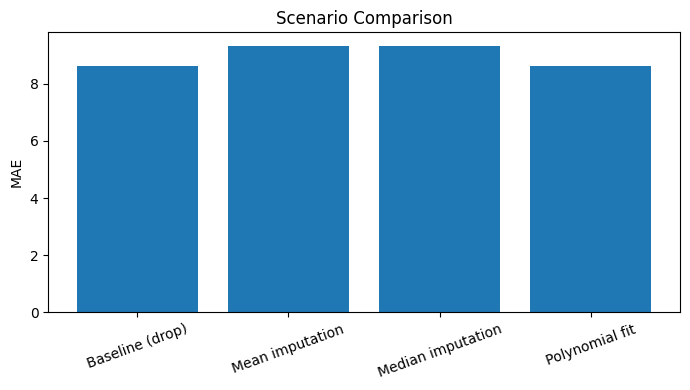

In [7]:
scenarios = {
    'Baseline (drop)': baseline_mae,
    'Mean imputation': mae_mean,
    'Median imputation': mae_median,
    'Polynomial fit': mae_poly,
}
plt.figure(figsize=(7, 4))
plt.bar(scenarios.keys(), scenarios.values())
plt.ylabel('MAE')
plt.title('Scenario Comparison')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [8]:
df_clean = df_clean.copy()
df_clean['pred'] = model.predict(df_clean[['x']])
df_clean['residual'] = df_clean['y'] - df_clean['pred']

subgroup_mae = df_clean.groupby('segment').apply(
    lambda g: mean_absolute_error(g['y'], g['pred'])
)
print(subgroup_mae)

segment
A     6.203859
B     5.960674
C    18.195281
dtype: float64


/var/folders/t_/qgn37cv10qq8rfl1z2whdr740000gn/T/ipykernel_13582/123958791.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subgroup_mae = df_clean.groupby('segment').apply(


<Figure size 700x400 with 0 Axes>

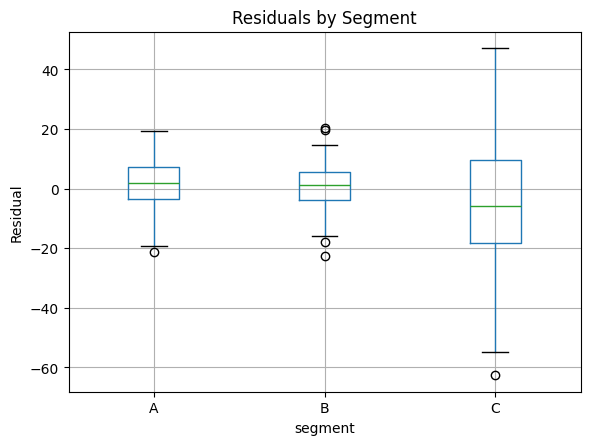

In [9]:
plt.figure(figsize=(7, 4))
df_clean.boxplot(column='residual', by='segment')
plt.title('Residuals by Segment')
plt.suptitle('')
plt.ylabel('Residual')
plt.show()